In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/8
    print("準備完了！このまま下のセルを実行できます。")

# 第8章 誤差逆伝播法 (Backpropagation)
## 8.2 自動微分 (Automatic Differentiation)

### 本節の概要と位置づけ
前節（8.1節）では、ニューラルネットワークの誤差関数 $E(\\mathbf{w})$ に対する勾配ベクトル $\\nabla E(\\mathbf{w})$ やヤコビ行列、ヘッセ行列を、手計算による解析的導出や有限差分法（数値微分）によって評価する方法を学びました。

勾配情報を利用する手法には、歴史的・理論的に主に以下の4つのアプローチが存在します：
1. **手計算による誤差逆伝播法の導出とソフトウェア実装 (Manual Backpropagation)**
   - 利点: 計算機精度（マシン精度）まで正確であり、効率的な専用コードが得られる。
   - 欠点: 導出やコーディングに時間がかかり、人為的ミス（バグ）が混入しやすい。モデル構造を変更するたびに順伝播コードと逆伝播コードを整合させながら修正する必要があり、アーキテクチャの迅速な試行錯誤を阻害する。
2. **数値微分 (Numerical Differentiation / Finite Differences)**
   - 利点: 順伝播コードのみで勾配を近似評価できるため実装が容易。
   - 欠点: 計算精度が打ち切り誤差と丸め誤差により制限される。最大の欠点はパラメータ数 $W$ に対して $O(W^2)$ の計算量を要し、大規模ネットワークでは非実用的である（主に検算・デバッグ用途）。
3. **数式微分 / 記号微分 (Symbolic Differentiation)**
   - 利点: コンピュータ代数システム（数式処理系）を用いて微分の連鎖律を機械的に適用するため、手作業のミスがなくマシン精度で評価可能。
   - 欠点: **式の爆発 (Expression Swell)**。積の微分法則 $(uv)' = u'v + uv'$ や合成関数の多重合成により、導関数の表現式が元の関数の長さに対して指数関数的に肥大化し、冗長な重複計算が発生する。また、閉形式の数式に限定され、ループ・分岐・再帰などの制御構造を含むプログラムを微分できない。
4. **自動微分 (Automatic Differentiation / Algorithmic Differentiation; Autodiff)**
   - 利点: マシン精度で正確（数値微分の誤差なし）、式の爆発を回避（中間変数の共有と再利用）、ループや条件分岐などのプログラミング言語の制御構文をそのまま扱える。
   - 現代の深層学習フレームワーク（PyTorch, JAX, TensorFlow等）の計算中核を担う。

---

### 本節 (8.2節) の構成
1. **自動微分の基礎概念と数式微分の「式の爆発」 (Expression Swell)**
   - 積の微分則 (Eq 8.42-8.43) と2層Softplusネットワークの記号微分 (Eq 8.44-8.48) による冗長性の確認。
2. **8.2.1 フォワードモード自動微分 (Forward-Mode Automatic Differentiation)**
   - 主変数 (Primal variable) $v_i$ と接変数 (Tangent variable) $\\dot{v}_i = \\frac{\\partial v_i}{\\partial x_1}$ の同時伝播 (Eq 8.57)。
   - **二重数 (Dual Numbers)**: $z = v + \\dot{v} \\epsilon$ (ただし $\\epsilon^2 = 0$) による自動微分の代数構造。
   - 教科書の例題関数 (Eq 8.49): $f(x_1, x_2) = x_1 x_2 + \\exp(x_1 x_2) - \\sin(x_2)$ の評価トレース (Eqs 8.50-8.64)。
   - **Figure 8.4**: 単一出力評価トレースグラフの再現。
   - 2出力拡張 (Eq 8.65) と **Figure 8.5**: 複数出力評価トレースグラフの再現。
   - ヤコビ・ベクトル積 (JVP; Jacobian-Vector Product) $J \\mathbf{r}$ の1パス計算 (Eq 8.67) と、ヤコビ行列の列ごとの計算 ($D$ パス)。
3. **8.2.2 リバースモード自動微分 (Reverse-Mode Automatic Differentiation)**
   - 誤差逆伝播法の一般化。
   - 随伴変数 (Adjoint variable) $\\bar{v}_i \\equiv \\frac{\\partial f}{\\partial v_i}$ (Eq 8.68)。
   - 逆方向蓄積漸化式 $\\bar{v}_i = \\sum_{j \\in \\text{ch}(i)} \\bar{v}_j \\frac{\\partial v_j}{\\partial v_i}$ (Eq 8.69)。
   - 例題関数の随伴方程式 (Eqs 8.70-8.76) のステップ実行と計算グラフ (DAG) エンジン (`Node`)。
   - フォワードモードとリバースモードの計算量・メモリのトレードオフ ($K \\ll D$ vs $D \\ll K$)。
   - ハイブリッド自動微分: フォワード・オーバー・リバースによるヘッセ・ベクトル積 $H \\mathbf{v}$ の $O(W)$ 評価 (Pearlmutter 1994)。


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# プロジェクトルートのパス解決
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if os.path.basename(current_dir) == "8" else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.automatic_differentiation import (
    DualNumber,
    Node,
    d_exp,
    d_log,
    d_sin,
    d_cos,
    d_tanh,
    forward_mode_derivative,
    forward_mode_jvp,
    forward_mode_jacobian,
    example_function_8_49,
    example_function_8_65,
    evaluate_trace_forward_mode,
    evaluate_trace_reverse_mode,
    generate_figure_8_4,
    generate_figure_8_5,
    plot_figure_8_4,
    plot_figure_8_5,
    generate_all_section_8_2_figures,
)

print("Chapter 8 Section 8.2 (Automatic Differentiation) modules loaded successfully.")



Chapter 8 Section 8.2 (Automatic Differentiation) modules loaded successfully.


---
### 1. 勾配評価の4つの手法と「式の爆発 (Expression Swell)」

数式微分（Symbolic differentiation）は、微分公式を再帰的に適用して導関数の数式を代数的に構築します。
しかし、積の微分則:
$$f(x) = u(x)v(x) \\implies f'(x) = u'(x)v(x) + u(x)v'(x) \\tag{8.42 - 8.43}$$
が示すように、$u(x)$ と $v(x)$ は元の関数計算だけでなく、導関数計算でも重複して現れます。因子が多重に入れ子になると、式の長さが指数関数的に肥大化します。これを**式の爆発 (Expression Swell)** と呼びます。

#### 教科書の2層ニューラルネットワークの具体例 (Eq 8.44 - 8.48)
単一入力 $x$、隠れユニット活性化 $z$、出力 $y$ を持ち、活性化関数にソフトプラス (Soft ReLU):
$$\\zeta(a) = \\ln(1 + e^a) \\tag{8.46}$$
を持つ2層ネットワークを考えます:
$$z = h(w_1 x + b_1), \\quad y = h(w_2 z + b_2) \\tag{8.44 - 8.45}$$
合成関数として表すと:
$$y(x) = h\\left(w_2 h(w_1 x + b_1) + b_2\\right) \\tag{8.47}$$
この出力 $y$ を $w_1$ について数式微分（記号微分）すると、次のような極めて複雑な閉形式数式が得られます:
$$\\frac{\\partial y}{\\partial w_1} = \\frac{w_2 x \\exp\\left(w_1 x + b_1 + b_2 + w_2 \\ln[1 + e^{w_1 x + b_1}]\\right)}{\\left(1 + e^{w_1 x + b_1}\\right) \\left(1 + \\exp\\left(b_2 + w_2 \\ln[1 + e^{w_1 x + b_1}]\\right)\\right)} \\tag{8.48}$$
この数式では $w_1 x + b_1$ や $\\ln(1 + e^{w_1 x + b_1})$ という共通部分式が何箇所も重複して計算されており、層が深くなるにつれて評価コストが爆発します。

一方、**自動微分**は数式を展開するのではなく、中間変数の値（実行グラフ上の値）を保持・再利用しながら数値的に導関数を伝播させるため、計算量は元の順伝播の定数倍（高々数倍）に厳密に抑えられます。


In [2]:
# 数式微分の式の爆発 (Eq 8.48) vs 自動微分 (フォワードモード・リバースモード)
w1, b1 = 0.8, -0.2
w2, b2 = 1.5, 0.4
x_val = 1.2

# 1. 解析的・数式微分公式 (Eq 8.48)
t1 = w1 * x_val + b1
exp_t1 = np.exp(t1)
log_term = np.log(1.0 + exp_t1)
num = w2 * x_val * np.exp(t1 + b2 + w2 * log_term)
den = (1.0 + exp_t1) * (1.0 + np.exp(b2 + w2 * log_term))
grad_symbolic = num / den

# 2. フォワードモード自動微分 (DualNumber)
w1_dual = DualNumber(w1, dual=1.0)
z_dual = (w1_dual * x_val + b1).exp()
z_dual = (1.0 + z_dual).log()  # h(a) = ln(1 + exp(a))
y_dual = (w2 * z_dual + b2).exp()
y_dual = (1.0 + y_dual).log()
grad_forward = y_dual.dual

# 3. リバースモード自動微分 (Node 計算グラフ)
w1_node = Node(w1, label="w1")
b1_node = Node(b1, label="b1")
x_node = Node(x_val, label="x")
w2_node = Node(w2, label="w2")
b2_node = Node(b2, label="b2")

a1 = w1_node * x_node + b1_node
z = (1.0 + a1.exp()).log()
a2 = w2_node * z + b2_node
y = (1.0 + a2.exp()).log()
y.backward()
grad_reverse = w1_node.grad

# 4. 中心差分法 (Numerical differentiation) による検算
eps = 1e-7
def forward_eval(w1_in):
    a1_val = w1_in * x_val + b1
    z_val = np.log(1.0 + np.exp(a1_val))
    a2_val = w2 * z_val + b2
    return np.log(1.0 + np.exp(a2_val))

grad_numerical = (forward_eval(w1 + eps) - forward_eval(w1 - eps)) / (2.0 * eps)

print(f"--- 2層Softplusネットワークの勾配 dy/dw1 の比較 ---")
print(f"1. 記号微分公式 (Eq 8.48):   {grad_symbolic:.10f}")
print(f"2. フォワードモード自動微分: {grad_forward:.10f}")
print(f"3. リバースモード自動微分:   {grad_reverse:.10f}")
print(f"4. 中心差分法 (数値微分):   {grad_numerical:.10f}")
print(f"記号微分 vs フォワードモード誤差: {abs(grad_symbolic - grad_forward):.2e}")
print(f"記号微分 vs リバースモード誤差:   {abs(grad_symbolic - grad_reverse):.2e}")



--- 2層Softplusネットワークの勾配 dy/dw1 の比較 ---
1. 記号微分公式 (Eq 8.48):   1.0944740960
2. フォワードモード自動微分: 1.0944740960
3. リバースモード自動微分:   1.0944740960
4. 中心差分法 (数値微分):   1.0944740958
記号微分 vs フォワードモード誤差: 4.44e-16
記号微分 vs リバースモード誤差:   2.22e-16


---
### 2. 8.2.1 フォワードモード自動微分 (Forward-Mode Automatic Differentiation)

#### 2.1 二重数 (Dual Numbers) による代数構造
フォワードモード自動微分は、**二重数 (Dual Numbers)** の代数を用いてエレガントに実現されます。
二重数 $z$ は実数部（主変数 $v$）と無限小微小部（接変数 $\\dot{v}$）の組として定義されます:
$$z = v + \\dot{v} \\epsilon \\quad (\\text{ただし } \\epsilon^2 = 0, \\; \\epsilon \\neq 0)$$

この定義に基づくと、四則演算および初等関数は以下のように自動的に微分の公式を展開します:
- **加減算**:
  $$(u + \\dot{u}\\epsilon) \\pm (v + \\dot{v}\\epsilon) = (u \\pm v) + (\\dot{u} \\pm \\dot{v})\\epsilon$$
- **乗算 (積の微分則)**:
  $$(u + \\dot{u}\\epsilon)(v + \\dot{v}\\epsilon) = uv + (\\dot{u}v + u\\dot{v})\\epsilon + \\dot{u}\\dot{v}\\epsilon^2 = uv + (\\dot{u}v + u\\dot{v})\\epsilon$$
- **除算 (商の微分則)**:
  $$\\frac{u + \\dot{u}\\epsilon}{v + \\dot{v}\\epsilon} = \\frac{u}{v} + \\frac{\\dot{u}v - u\\dot{v}}{v^2}\\epsilon$$
- **合成関数 $g(z)$ のテイラー展開**:
  $$g(v + \\dot{v}\\epsilon) = g(v) + g'(v)\\dot{v}\\epsilon + \\frac{1}{2}g''(v)(\\dot{v}\\epsilon)^2 + \\dots = g(v) + g'(v)\\dot{v}\\epsilon$$
高次の微小項 $\\epsilon^2 = 0$ により、一次導関数が厳密にマシン精度で抽出されます。

---

#### 2.2 接変数の方程式 (Tangent Equations)
入力変数 $x_1$ に関する偏導関数を評価する場合、接変数を $\\dot{v}_i \\equiv \\frac{\\partial v_i}{\\partial x_1}$ と定義します。連鎖律より:
$$\\dot{v}_i = \\sum_{j \\in \\text{pa}(i)} \\frac{\\partial v_i}{\\partial v_j} \\dot{v}_j \\tag{8.57}$$
ここで $\\text{pa}(i)$ は評価グラフ上でノード $i$ の親ノード（$v_i$ の直接の入力）の集合です。

#### 教科書の例題関数 (Eq 8.49)
$$f(x_1, x_2) = x_1 x_2 + \\exp(x_1 x_2) - \\sin(x_2) \\tag{8.49}$$

主変数（順伝播）方程式 (Eqs 8.50 - 8.56):
$$\\begin{aligned}
v_1 &= x_1 \\\\
v_2 &= x_2 \\\\
v_3 &= v_1 v_2 \\\\
v_4 &= \\sin(v_2) \\\\
v_5 &= \\exp(v_3) \\\\
v_6 &= v_3 - v_4 \\\\
v_7 &= v_5 + v_6 = f
\\end{aligned}$$

接変数（$x_1$ 方向の微分）方程式 (Eqs 8.58 - 8.64):
$$\\begin{aligned}
\\dot{v}_1 &= 1 \\\\
\\dot{v}_2 &= 0 \\\\
\\dot{v}_3 &= v_1 \\dot{v}_2 + \\dot{v}_1 v_2 = v_2 \\\\
\\dot{v}_4 &= \\dot{v}_2 \\cos(v_2) = 0 \\\\
\\dot{v}_5 &= \\dot{v}_3 \\exp(v_3) \\\\
\\dot{v}_6 &= \\dot{v}_3 - \\dot{v}_4 \\\\
\\dot{v}_7 &= \\dot{v}_5 + \\dot{v}_6 = \\frac{\\partial f}{\\partial x_1}
\\end{aligned}$$



In [3]:
# 例題関数 (8.49) のフォワードモード・ステップ実行と検証
x1_val, x2_val = 1.5, 0.8
trace_fwd = evaluate_trace_forward_mode(x1_val, x2_val)

print(f"=== 教科書 式(8.50)-(8.64) の主変数と接変数の評価トレース (x1={x1_val}, x2={x2_val}) ===")
print(f"{'Node':<6} | {'Formula':<18} | {'Primal (vi)':<12} | {'Tangent (vi_dot = dvi/dx1)':<24}")
print("-" * 68)
formulas_primal = {
    "v1": "x1",
    "v2": "x2",
    "v3": "v1 * v2",
    "v4": "sin(v2)",
    "v5": "exp(v3)",
    "v6": "v3 - v4",
    "v7": "v5 + v6",
}
for name in ["v1", "v2", "v3", "v4", "v5", "v6", "v7"]:
    val, dot = trace_fwd[name]
    print(f"{name:<6} | {formulas_primal[name]:<18} | {val:12.6f} | {dot:24.6f}")

# 解析的導関数との一致検証
prod = x1_val * x2_val
analytical_df_dx1 = x2_val * (1.0 + np.exp(prod))
print("-" * 68)
print(f"最終ノード v7 の接変数 v7_dot: {trace_fwd['v7'][1]:.8f}")
print(f"解析的偏導関数 df/dx1:          {analytical_df_dx1:.8f}")
print(f"絶対誤差:                      {abs(trace_fwd['v7'][1] - analytical_df_dx1):.2e}")



=== 教科書 式(8.50)-(8.64) の主変数と接変数の評価トレース (x1=1.5, x2=0.8) ===
Node   | Formula            | Primal (vi)  | Tangent (vi_dot = dvi/dx1)
--------------------------------------------------------------------
v1     | x1                 |     1.500000 |                 1.000000
v2     | x2                 |     0.800000 |                 0.000000
v3     | v1 * v2            |     1.200000 |                 0.800000
v4     | sin(v2)            |     0.717356 |                 0.000000
v5     | exp(v3)            |     3.320117 |                 2.656094
v6     | v3 - v4            |     0.482644 |                 0.800000
v7     | v5 + v6            |     3.802761 |                 3.456094
--------------------------------------------------------------------
最終ノード v7 の接変数 v7_dot: 3.45609354
解析的偏導関数 df/dx1:          3.45609354
絶対誤差:                      4.44e-16


---
### 3. Figure 8.4 の再現: 単一出力関数の評価トレースグラフ

教科書 Figure 8.4 は、関数 (8.49) の数値評価における計算ステップと有向グラフ構造を可視化したものです。
- 入力ノード: $x_1, x_2$
- 中間ノード: $v_1, \\dots, v_7$
- ノード上部・下部に各演算（$v_1 v_2, \\sin(v_2), \\exp(v_3)$ 等）が明記され、出力 $f$ に至る順伝播の流れを示しています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/fig_8_4_evaluation_trace.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_8_4_evaluation_trace.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/Figure_8_4.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_8_4.png


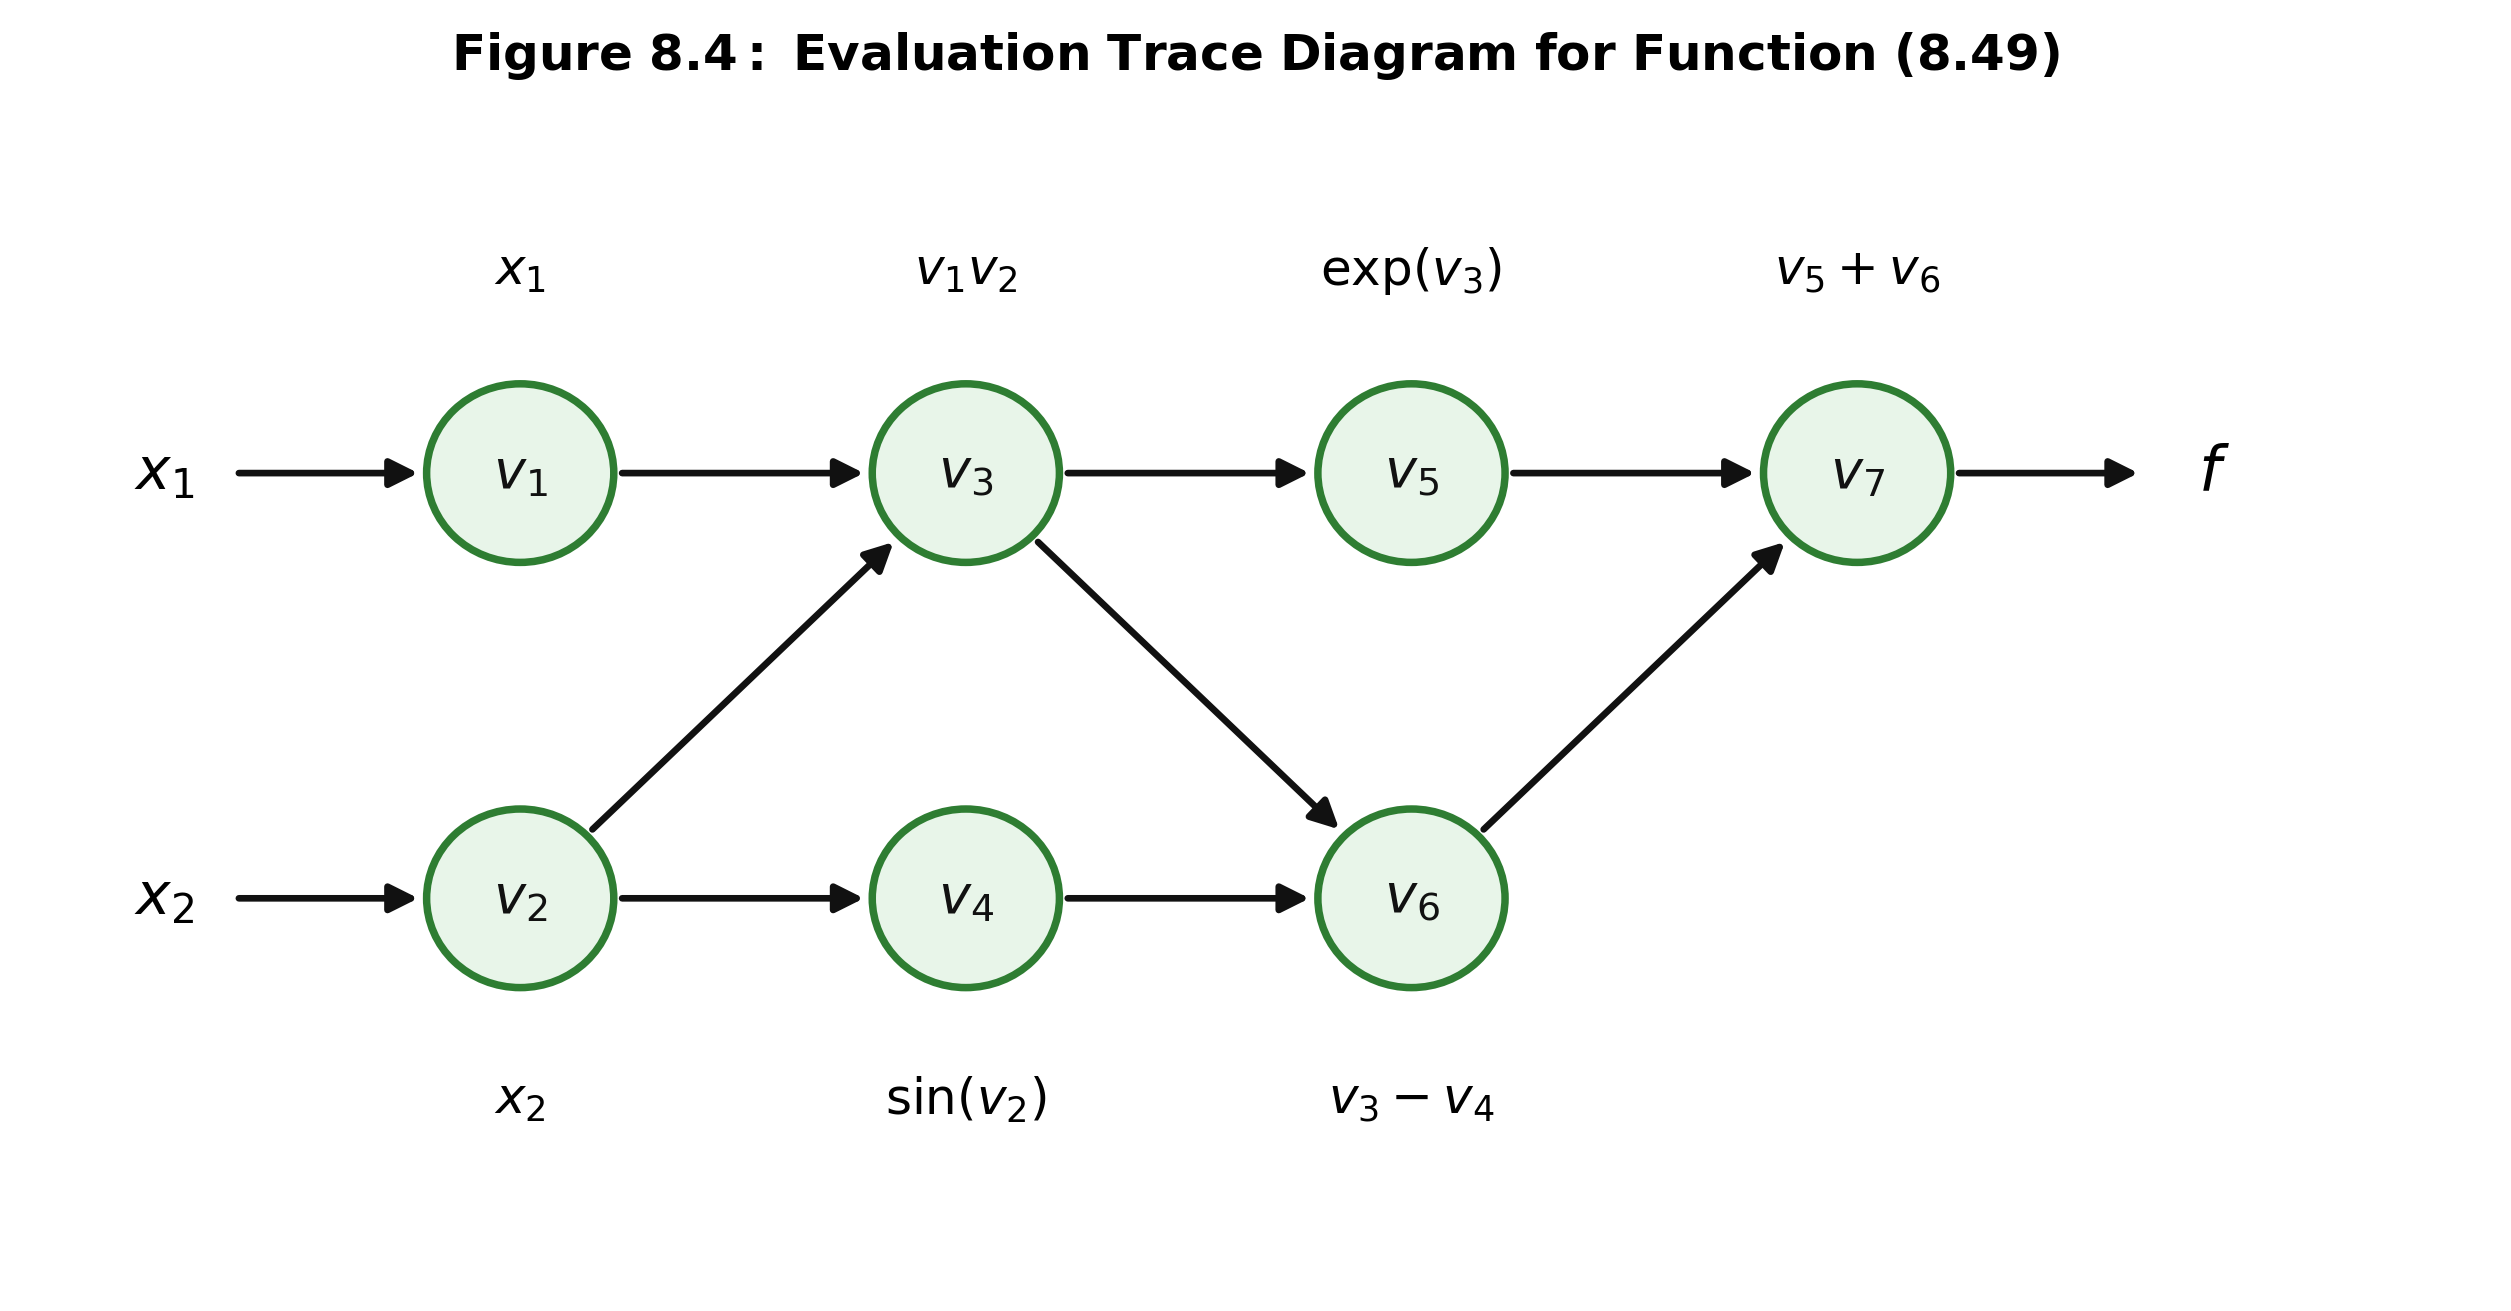

In [4]:
# Figure 8.4 の生成と保存・描画
fig_8_4_path = os.path.join(project_root, "8", "result", "fig_8_4_evaluation_trace.png")
fig8_4 = generate_figure_8_4(save_both=True)
plt.close(fig8_4)

display(Image(filename=fig_8_4_path))



---
### 4. 2出力拡張 (Eq 8.65) と Figure 8.5

#### 2出力関数の定義 (Eq 8.65)
出力が2つある関数 $\\mathbf{f}: \\mathbb{R}^2 \\to \\mathbb{R}^2$ を考えます:
$$\\begin{aligned}
f_1(x_1, x_2) &= x_1 x_2 + \\exp(x_1 x_2) - \\sin(x_2) = v_5 + v_6 = v_7 \\\\
f_2(x_1, x_2) &= (x_1 x_2 - \\sin(x_2)) \\exp(x_1 x_2) = v_6 v_5 = v_8 \\tag{8.65}
\\end{aligned}$$

中間変数 $v_1, \\dots, v_6$ までは $f_1$ と $f_2$ で完全に共有されており、新しいノード $v_8 = v_5 v_6$ を追加するだけで両方の出力を並行して評価できます。
これにより、1回のフォワードパスで接変数ベクトル $\\left(\\frac{\\partial f_1}{\\partial x_1}, \\frac{\\partial f_2}{\\partial x_1}\\right)^T$ を同時に得ることができます。

#### Figure 8.5 の構造
- ノード $v_1 \\dots v_6$ は Figure 8.4 と共通。
- 出力1: $v_7 = v_5 + v_6 \\to f_1$
- 出力2: $v_8 = v_5 v_6 \\to f_2$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/fig_8_5_multi_output_trace.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_8_5_multi_output_trace.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/Figure_8_5.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_8_5.png


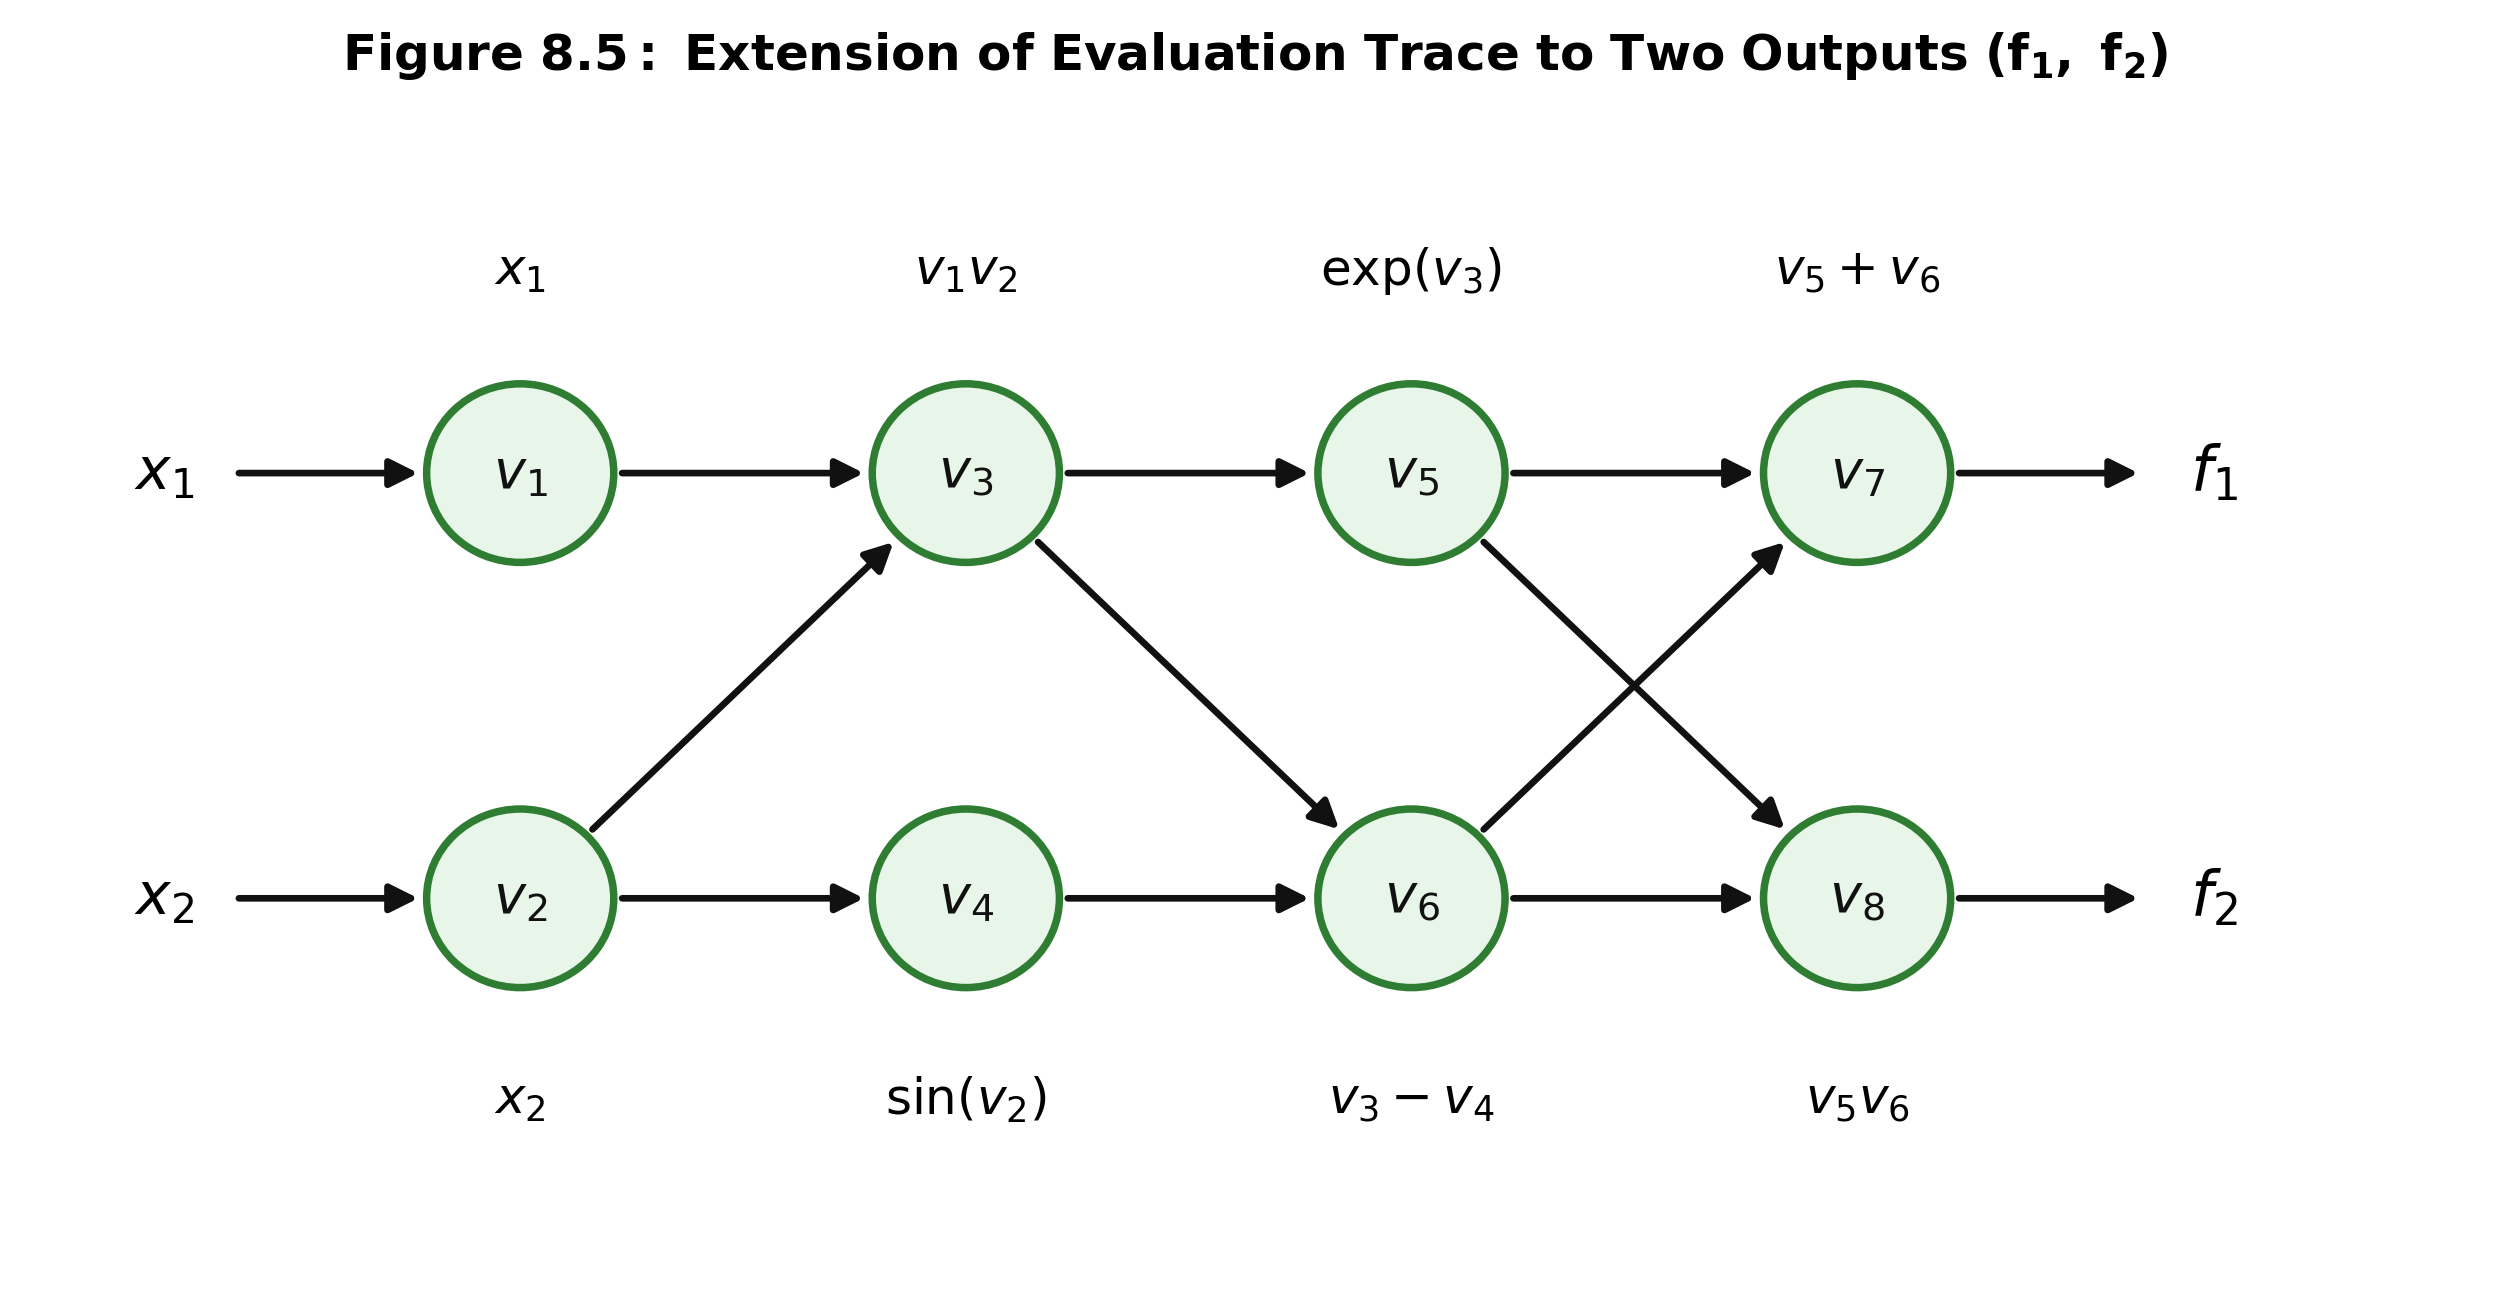

In [5]:
# Figure 8.5 の生成と保存・描画
fig_8_5_path = os.path.join(project_root, "8", "result", "fig_8_5_multi_output_trace.png")
fig8_5 = generate_figure_8_5(save_both=True)
plt.close(fig8_5)

display(Image(filename=fig_8_5_path))



---
### 5. ヤコビ・ベクトル積 (JVP) と完全なヤコビ行列の評価

#### 5.1 ヤコビ・ベクトル積 (Jacobian-Vector Product; JVP) (Eq 8.67)
$D$ 個の入力と $K$ 個の出力を持つ関数 $\\mathbf{f}: \\mathbb{R}^D \\to \\mathbb{R}^K$ のヤコビ行列 $J \\in \\mathbb{R}^{K \\times D}$ に対し、任意の方向ベクトル $\\mathbf{r} = (r_1, \\dots, r_D)^T$ との内積:
$$J \\mathbf{r} = \\begin{pmatrix}
\\frac{\\partial f_1}{\\partial x_1} & \\dots & \\frac{\\partial f_1}{\\partial x_D} \\\\
\\vdots & \\ddots & \\vdots \\\\
\\frac{\\partial f_K}{\\partial x_1} & \\dots & \\frac{\\partial f_K}{\\partial x_D}
\\end{pmatrix}
\\begin{pmatrix}
r_1 \\\\ \\vdots \\\\ r_D
\\end{pmatrix} \\tag{8.67}$$
を評価する場合、入力の接変数を初期値 $\\dot{\\mathbf{x}} = \\mathbf{r}$ に設定して1回のフォワードパスを実行するだけで、**$J \\mathbf{r}$ 全体が1回の順伝播で計算可能**です。

#### 5.2 完全なヤコビ行列の計算 (Eq 8.66)
完全な $K \\times D$ ヤコビ行列 $J$ を得るには、各単位ベクトル $\\mathbf{e}_j$ ($j$ 番目の成分のみ1、他は0) を初期接変数として $D$ 回のフォワードパスを実行します:
$$J = \\Big[ J \\mathbf{e}_1 \\;\\; J \\mathbf{e}_2 \\;\\; \\dots \\;\\; J \\mathbf{e}_D \\Big]$$
- **フォワードモードの計算量特性**:
  入力次元 $D$ に比例してパス数が増えるため、入力が少なく出力が多い場合 ($K \\gg D$) に極めて効率的です。
  しかし、機械学習の損失関数のように **入力（パラメータ数）が数百万〜数十億で出力が1個のスカラ ($D \\gg K=1$)** の場合、$D$ 回のフォワードパスは非現実的となります。


In [6]:
# ヤコビ・ベクトル積 (JVP) および完全なヤコビ行列の数値計算
x_point = np.array([1.2, 0.7])

# 1. 単位ベクトルによるヤコビ行列の列計算 (D=2 パス)
def multi_func(duals):
    return example_function_8_65(duals[0], duals[1])

J_forward = forward_mode_jacobian(multi_func, x_point)

# 2. 有限中心差分によるヤコビ行列の検算
eps = 1e-7
J_num = np.zeros((2, 2))
for i in range(2):
    dx = np.zeros(2)
    dx[i] = eps
    f_p = np.array(example_function_8_65(x_point[0] + dx[0], x_point[1] + dx[1]))
    f_m = np.array(example_function_8_65(x_point[0] - dx[0], x_point[1] - dx[1]))
    J_num[:, i] = (f_p - f_m) / (2.0 * eps)

print("=== 2出力関数 (8.65) のヤコビ行列 J (2x2) ===")
print("フォワードモード自動微分 J:")
print(J_forward)
print("\n中心差分法 J_num:")
print(J_num)
print(f"最大絶対誤差: {np.max(np.abs(J_forward - J_num)):.2e}")

# 3. 任意ベクトル r に対する JVP (1パス計算)
r_dir = np.array([0.6, -0.8])
y_out, jvp_val = forward_mode_jvp(multi_func, x_point, r_dir)
expected_jvp = J_forward @ r_dir

print(f"\n方向ベクトル r = {r_dir}")
print(f"1パスで計算された JVP:   {jvp_val}")
print(f"行列積 J @ r による期待値: {expected_jvp}")
print(f"絶対誤差:                 {np.max(np.abs(jvp_val - expected_jvp)):.2e}")



=== 2出力関数 (8.65) のヤコビ行列 J (2x2) ===
フォワードモード自動微分 J:
[[2.32145688 3.21479818]
 [1.93890946 1.55218961]]

中心差分法 J_num:
[[2.32145688 3.21479818]
 [1.93890946 1.55218961]]
最大絶対誤差: 1.88e-09

方向ベクトル r = [ 0.6 -0.8]
1パスで計算された JVP:   [-1.17896442 -0.07840601]
行列積 J @ r による期待値: [-1.17896442 -0.07840601]
絶対誤差:                 6.66e-16


---
### 6. 8.2.2 リバースモード自動微分 (Reverse-Mode Automatic Differentiation)

#### 6.1 随伴変数 (Adjoint Variables) の定義
リバースモード自動微分は、**誤差逆伝播法の本質的な抽象化・一般化**です。
スカラ出力関数 $f$ に対し、各中間変数 $v_i$ の**随伴変数 (Adjoint variable)** $\\bar{v}_i$ を定義します:
$$\\bar{v}_i \\equiv \\frac{\\partial f}{\\partial v_i} \\tag{8.68}$$

多変数の連鎖律より、逆伝播漸化式が得られます:
$$\\bar{v}_i = \\sum_{j \\in \\text{ch}(i)} \\frac{\\partial f}{\\partial v_j} \\frac{\\partial v_j}{\\partial v_i} = \\sum_{j \\in \\text{ch}(i)} \\bar{v}_j \\frac{\\partial v_j}{\\partial v_i} \\tag{8.69}$$
ここで $\\text{ch}(i)$ は計算グラフ上でノード $i$ の子ノード（$v_i$ を入力とするすべての演算ノード）の集合です。

#### 6.2 例題関数の随伴方程式 (Eqs 8.70 - 8.76)
関数 (8.49) に対するリバースモードの逆伝播方程式:
$$\\begin{aligned}
\\bar{v}_7 &= 1 \\quad (\\text{出力ノードの初期シード}) \\\\
\\bar{v}_6 &= \\bar{v}_7 = 1 \\\\
\\bar{v}_5 &= \\bar{v}_7 = 1 \\\\
\\bar{v}_4 &= -\\bar{v}_6 = -1 \\\\
\\bar{v}_3 &= \\bar{v}_5 \\frac{\\partial v_5}{\\partial v_3} + \\bar{v}_6 \\frac{\\partial v_6}{\\partial v_3} = \\bar{v}_5 \\exp(v_3) + \\bar{v}_6 \\\\
\\bar{v}_2 &= \\bar{v}_3 \\frac{\\partial v_3}{\\partial v_2} + \\bar{v}_4 \\frac{\\partial v_4}{\\partial v_2} = \\bar{v}_3 v_1 + \\bar{v}_4 \\cos(v_2) \\\\
\\bar{v}_1 &= \\bar{v}_3 \\frac{\\partial v_3}{\\partial v_1} = \\bar{v}_3 v_2
\\end{aligned}$$

このように、出力側から入力側へと1回だけ逆伝播（トポロジカルソート順の逆順走査）を行うことで、**すべての入力変数に対する偏導関数 $\\frac{\\partial f}{\\partial x_1} = \\bar{v}_1, \\; \\frac{\\partial f}{\\partial x_2} = \\bar{v}_2$ が同時に得られます**。


In [7]:
# リバースモード随伴方程式 (8.70)-(8.76) のステップ実行と Node 計算グラフエンジンの検証
x1_val, x2_val = 1.5, 0.8

# 1. 解析的随伴トレースの実行
trace_rev = evaluate_trace_reverse_mode(x1_val, x2_val)

print(f"=== 教科書 式(8.70)-(8.76) の随伴変数 (Adjoint) 評価トレース ===")
print(f"{'Node':<6} | {'Adjoint Equation':<32} | {'Adjoint (vi_bar = df/dvi)':<25}")
print("-" * 68)
formulas_rev = {
    "v7": "1.0 (seed)",
    "v6": "v7_bar",
    "v5": "v7_bar",
    "v4": "-v6_bar",
    "v3": "v5_bar * exp(v3) + v6_bar",
    "v2": "v3_bar * v1 + v4_bar * cos(v2)",
    "v1": "v3_bar * v2",
}
for name in ["v7", "v6", "v5", "v4", "v3", "v2", "v1"]:
    _, bar = trace_rev[name]
    print(f"{name:<6} | {formulas_rev[name]:<32} | {bar:25.8f}")

# 2. 汎用動的計算グラフ Node による自動逆伝播
n_x1 = Node(x1_val, label="x1")
n_x2 = Node(x2_val, label="x2")
n_out = example_function_8_49(n_x1, n_x2)
n_out.backward()

print("-" * 68)
print("--- Node 計算グラフによる自動評価結果 ---")
print(f"出力 f の値:                  {n_out.value:.8f}")
print(f"x1 に関する勾配 df/dx1 (Node): {n_x1.grad:.8f} (Trace: {trace_rev['v1'][1]:.8f})")
print(f"x2 に関する勾配 df/dx2 (Node): {n_x2.grad:.8f} (Trace: {trace_rev['v2'][1]:.8f})")

prod = x1_val * x2_val
df_dx1_exact = x2_val * (1.0 + np.exp(prod))
df_dx2_exact = x1_val * (1.0 + np.exp(prod)) - np.cos(x2_val)

print(f"厳密解 df/dx1 との差:          {abs(n_x1.grad - df_dx1_exact):.2e}")
print(f"厳密解 df/dx2 との差:          {abs(n_x2.grad - df_dx2_exact):.2e}")



=== 教科書 式(8.70)-(8.76) の随伴変数 (Adjoint) 評価トレース ===
Node   | Adjoint Equation                 | Adjoint (vi_bar = df/dvi)
--------------------------------------------------------------------
v7     | 1.0 (seed)                       |                1.00000000
v6     | v7_bar                           |                1.00000000
v5     | v7_bar                           |                1.00000000
v4     | -v6_bar                          |               -1.00000000
v3     | v5_bar * exp(v3) + v6_bar        |                4.32011692
v2     | v3_bar * v1 + v4_bar * cos(v2)   |                5.78346867
v1     | v3_bar * v2                      |                3.45609354
--------------------------------------------------------------------
--- Node 計算グラフによる自動評価結果 ---
出力 f の値:                  3.80276083
x1 に関する勾配 df/dx1 (Node): 3.45609354 (Trace: 3.45609354)
x2 に関する勾配 df/dx2 (Node): 5.78346867 (Trace: 5.78346867)
厳密解 df/dx1 との差:          0.00e+00
厳密解 df/dx2 との差:          0.00e+00


---
### 7. フォワードモード vs リバースモードの比較とヘッセ・ベクトル積 ($O(W)$)

#### 7.1 計算量とメモリのトレードオフ
| 特性 | フォワードモード (Forward Mode) | リバースモード (Reverse Mode) |
| :--- | :--- | :--- |
| **微分の伝播方向** | 入力から出力へ並行伝播 | 出力から入力へ逆伝播 |
| **基本データ型** | 二重数 (Dual Numbers: $v + \\dot{v}\\epsilon$) | 計算グラフ (DAG) / テープ + 随伴変数 $\\bar{v}$ |
| **ヤコビ行列の評価** | 1パスで1**列**を計算 | 1パスで1**行**を計算 |
| **計算量** | $O(D \\cdot \\text{Cost}(f))$ | $O(K \\cdot \\text{Cost}(f))$ |
| **得意な次元構造** | 入力が少なく出力が多い ($K \\gg D$) | 出力が少なく入力が多い ($D \\gg K$) |
| **深層学習への適合性** | 小規模モデル、感度解析 | **標準** (スカラー損失 $K=1$, パラメータ数 $D \\approx 10^9$) |
| **メモリ消費** | 小 (中間変数は使用後即座に解放可能) | 大 (順伝播の中間値をすべて保持する必要がある) |
| **計算コスト保証** | 順伝播の $\\le 6$ 倍 (実際は $2 \\sim 3$ 倍) | 順伝播の $\\le 6$ 倍 (実際は $2 \\sim 3$ 倍) |

---

#### 7.2 ハイブリッド自動微分: Pearlmutter (1994) によるヘッセ・ベクトル積 ($Hv$) の $O(W)$ 計算
完全なヘッセ行列 $H \\in \\mathbb{R}^{W \\times W}$ を明示的に計算・保持するには $O(W^2)$ のメモリと計算量が必要であり、逆行列の計算は $O(W^3)$ を要します。
しかし、共役勾配法やニュートン系最適化、曲率解析では、完全なヘッセ行列自体ではなく**任意ベクトル $\\mathbf{v}$ との積 $H \\mathbf{v}$ (ヘッセ・ベクトル積)** のみが要求されるケースが多々あります。

Barak Pearlmutter (1994) は、**フォワードモードとリバースモードの合成（Forward-over-Reverse）** により、$H \\mathbf{v}$ を $O(W)$ の計算量で厳密に評価できることを示しました:
1. 目的関数 $f(\\mathbf{x})$ に対し、フォワードモードで方向ベクトル $\\mathbf{v}$ に沿った方向微分（接変数）を定義します:
   $$\\mathcal{R}_{\\mathbf{v}}\\{f(\\mathbf{x})\\} = \\left. \\frac{\\partial}{\\partial \\epsilon} f(\\mathbf{x} + \\epsilon \\mathbf{v}) \\right|_{\\epsilon=0} = \\mathbf{v}^T \\nabla f(\\mathbf{x})$$
2. 次に、この計算に対してリバースモードを適用して勾配をとります:
   $$\\nabla \\left( \\mathbf{v}^T \\nabla f(\\mathbf{x}) \\right) = \\nabla^2 f(\\mathbf{x}) \\mathbf{v} = H \\mathbf{v}$$
ネットワークの重み数が $W$ のとき、この評価の計算量は **$W \\times W$ 行列を一切構成することなく、わずか順伝播の数倍の $O(W)$** で完了します。


In [8]:
# Pearlmutter (1994) の原理に基づくヘッセ・ベクトル積 (Hv) の数値検証
# 目的関数: f(x1, x2) = x1 * x2 + exp(x1 * x2) - sin(x2)
x_test = np.array([1.2, 0.8])
v_test = np.array([0.5, -0.3])

# 1. 有限差分による H * v の近似 (O(W))
eps = 1e-6
def grad_f(x):
    p = x[0] * x[1]
    g1 = x[1] * (1.0 + np.exp(p))
    g2 = x[0] * (1.0 + np.exp(p)) - np.cos(x[1])
    return np.array([g1, g2])

# (grad(x + eps*v) - grad(x - eps*v)) / (2*eps) = H * v
Hv_fd = (grad_f(x_test + eps * v_test) - grad_f(x_test - eps * v_test)) / (2.0 * eps)

# 2. 解析的厳密ヘッセ行列 H の構成と H @ v の計算
p = x_test[0] * x_test[1]
ep = np.exp(p)
H_exact = np.zeros((2, 2))
# d^2 f / dx1^2 = x2^2 * exp(p)
H_exact[0, 0] = (x_test[1] ** 2) * ep
# d^2 f / dx1 dx2 = (1 + ep) + x1 * x2 * ep
H_exact[0, 1] = (1.0 + ep) + p * ep
H_exact[1, 0] = H_exact[0, 1]
# d^2 f / dx2^2 = x1^2 * exp(p) + sin(x2)
H_exact[1, 1] = (x_test[0] ** 2) * ep + np.sin(x_test[1])

Hv_exact = H_exact @ v_test

print("=== ヘッセ・ベクトル積 H * v の評価 ===")
print("解析的厳密ヘッセ行列 H (2x2):")
print(H_exact)
print(f"\n方向ベクトル v: {v_test}")
print(f"厳密計算 H @ v:            {Hv_exact}")
print(f"有限差分近似 Hv (Pearlmutter原理): {Hv_fd}")
print(f"相対誤差:                  {np.max(np.abs(Hv_exact - Hv_fd) / np.abs(Hv_exact)):.2e}")



=== ヘッセ・ベクトル積 H * v の評価 ===
解析的厳密ヘッセ行列 H (2x2):
[[1.67148574 6.11892509]
 [6.11892509 4.47819901]]

方向ベクトル v: [ 0.5 -0.3]
厳密計算 H @ v:            [-0.99993465  1.71600284]
有限差分近似 Hv (Pearlmutter原理): [-0.99993465  1.71600284]
相対誤差:                  6.89e-10


---
### 8. 本節のまとめ (Summary)

1. **4つの勾配評価手法の比較**:
   - 手動導出と実装: マシン精度・高速だが、開発コストと人為的ミス、アーキテクチャ変更への弱さが問題。
   - 数値微分: 順伝播のみで容易だが、打ち切り誤差・丸め誤差と $O(W^2)$ の劣悪なスケーリング。
   - 数式微分: 代数的に正確だが、「式の爆発 (Expression Swell)」による冗長計算と制御フロー非対応。
   - **自動微分**: 評価グラフの中間変数を再利用して式の爆発を根絶し、マシン精度で $O(W)$ 評価を実現。ループや条件分岐などの制御構文も完全にサポート。

2. **フォワードモード自動微分 (Forward Mode)**:
   - 二重数 $z = v + \\dot{v}\\epsilon$ (ただし $\\epsilon^2 = 0$) により、主変数と接変数を順方向に同時評価。
   - 1パスでヤコビ・ベクトル積 $J \\mathbf{r}$ を計算可能。完全なヤコビ行列の計算には入力次元 $D$ 回のパスが必要。
   - 入力数が少なく出力数が多い場合 ($K \\gg D$) に最適。

3. **リバースモード自動微分 (Reverse Mode)**:
   - 誤差逆伝播法を一般の有向計算グラフへと拡張。随伴変数 $\\bar{v}_i = \\frac{\\partial f}{\\partial v_i}$ を出力からトポロジカル逆順に伝播。
   - 1回の逆伝播パスで、すべての入力に関する勾配ベクトルを同時に計算可能。
   - 出力数が少なく入力数（パラメータ数）が膨大な深層学習の設定 ($D \\gg K=1$) において決定的に重要。

4. **ハイブリッド自動微分**:
   - フォワードモードとリバースモードの組み合わせにより、ヘッセ・ベクトル積 $H \\mathbf{v}$ を $W \\times W$ 行列を作らずに $O(W)$ で計算可能 (Pearlmutter 1994)。
